# Notebook 04 - Regression RUL

Ce notebook estime la duree de vie residuelle des equipements et evalue la qualite de l'alerte en zone critique.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import prepare_raw_datasets
from src.feature_engineering import build_feature_table, temporal_train_test_split, get_feature_columns
from src.project_pipeline import run_full_training
from src.models import train_classifiers, train_rul_models
from src.evaluation import evaluate_classifier, evaluate_regressor
from src.utils import COLOR_PALETTE, RANDOM_STATE, SENSOR_COLUMNS, CRITICAL_RUL_THRESHOLD

plt.style.use("seaborn-v0_8")
sns.set_palette([COLOR_PALETTE["accent"], COLOR_PALETTE["success"], COLOR_PALETTE["info"], COLOR_PALETTE["danger"]])
pd.set_option("display.max_columns", 120)


## 1. Entrainement des modeles RUL

Les modeles compares sont une baseline constante, une Random Forest, un SVR et XGBoost s'il est disponible.


In [2]:
bundle = prepare_raw_datasets(PROJECT_ROOT)
features = build_feature_table(bundle, PROJECT_ROOT)
train_df, test_df = temporal_train_test_split(features)
feature_columns = get_feature_columns(features)

regressors = train_rul_models(train_df)
list(regressors)


['dummy_rul', 'rf_rul', 'svr_rul']

In [3]:
rul_rows = []
rul_predictions = {}
for name, artifact in regressors.items():
    metrics, preds = evaluate_regressor(artifact, test_df, feature_columns)
    rul_rows.append({"model": name, **metrics})
    rul_predictions[name] = preds
rul_results = pd.DataFrame(rul_rows).sort_values("mae")
rul_results


,model,mae,rmse,r2,nasa_score,critical_zone_mae
2,svr_rul,299.247755,316.378100,-8.773491,2.372618e+17,417.176939
0,dummy_rul,409.802499,422.113228,-16.397820,9.972024e+21,526.147059
1,rf_rul,412.104139,450.184067,-18.788695,1.355112e+43,619.187765


## 2. RUL predit vs RUL reel

Le meilleur modele est compare a la diagonale ideale afin d'evaluer les sous-estimations et surestimations.


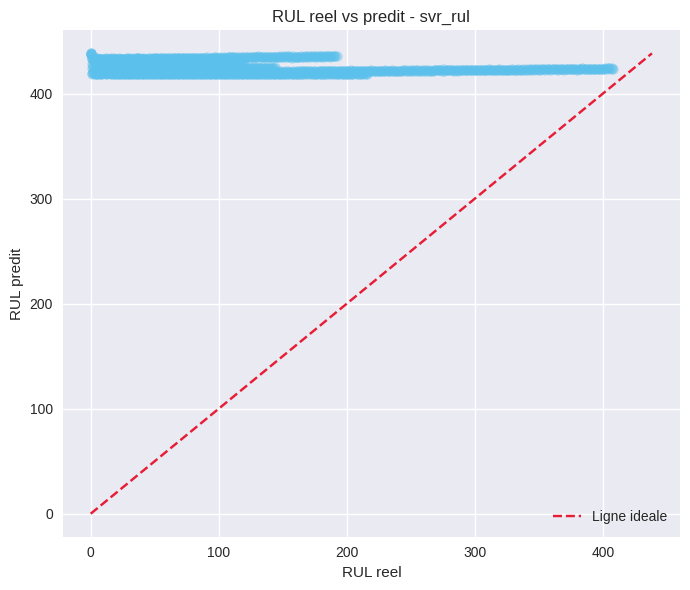

In [4]:
best_rul_model = rul_results.iloc[0]["model"]
best_rul_preds = rul_predictions[best_rul_model]

plt.figure(figsize=(7, 6))
plt.scatter(best_rul_preds["rul_hours"], best_rul_preds["predicted_rul"], alpha=0.4, color=COLOR_PALETTE["info"])
max_val = float(max(best_rul_preds["rul_hours"].max(), best_rul_preds["predicted_rul"].max()))
plt.plot([0, max_val], [0, max_val], linestyle="--", color=COLOR_PALETTE["danger"], label="Ligne ideale")
plt.title(f"RUL reel vs predit - {best_rul_model}")
plt.xlabel("RUL reel")
plt.ylabel("RUL predit")
plt.legend()
plt.tight_layout()
plt.show()


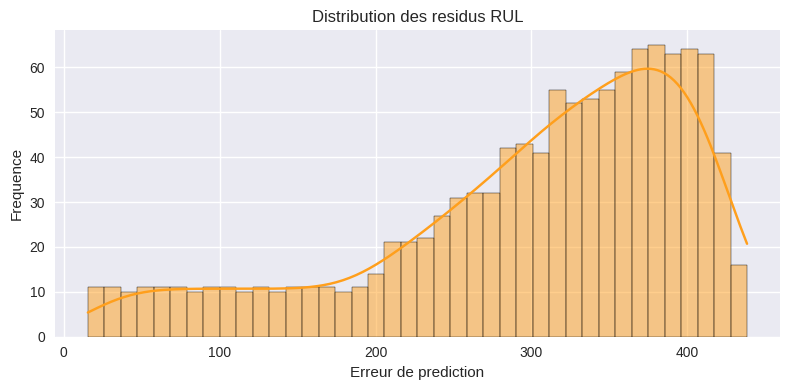

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(best_rul_preds["residual"], bins=40, kde=True, color=COLOR_PALETTE["accent"])
plt.title("Distribution des residus RUL")
plt.xlabel("Erreur de prediction")
plt.ylabel("Frequence")
plt.tight_layout()
plt.show()


## 3. Zone critique

Nous evaluons explicitement les observations dont la RUL reelle est inferieure au seuil critique.


In [6]:
critical_zone = best_rul_preds[best_rul_preds["rul_hours"] < CRITICAL_RUL_THRESHOLD]
critical_zone.head()


,datetime,machineID,rul_hours,predicted_rul,residual
533,2015-03-18 11:00:00,2,19.0,432.885674,413.885674
534,2015-03-18 12:00:00,2,18.0,432.575986,414.575986
535,2015-03-18 13:00:00,2,17.0,433.407997,416.407997
536,2015-03-18 14:00:00,2,16.0,431.820837,415.820837
537,2015-03-18 15:00:00,2,15.0,433.296625,418.296625


## 4. Conclusion RUL

La performance en MAE globale est completee par une lecture metier de la zone critique, qui est la plus importante pour la maintenance anticipative.
